EDGE DETECTION: L'ALGORITMO DI CANNY

Se chiudi gli occhi e provi ad immaginare un oggetto, non vedi i singoli pixel colorati, vedi i contorni.
I bordi sono le ossa dell'immagine, ciò che da struttura e forma al caos dei dati visivi.

Capire come funziona l'algoritmo di Canny Edge, significa capire come una macchina inizia a distinguere dove finisce il tavolo e dove inizia la sedia.

Canny Edge Detection: algoritmo per rilevare i contorni (bordi) in un'immagine, sviluppato da John Canny nel 1986. E' considerato lo standard de facto per l'edge detection perchè ottimizza tre criteri insieme: bassa percentuale di errore; buona localizzazione del bordo; risposta singola per bordo (non rileva lo stesso bordo più volte)

Ma per arrivare alla precisione di Canny dobbiamo prima capire come si misura il cambiamento

Pipeline dell'algoritmo, 5 step:
1.  Riduzione del rumore
    Prima di cercare i bordi, sfoca l'immagine con Gaussian Blur. Senza questo step, il rumore genera falsi bordi ovunque.
2.  Calcolo del gradiente
Applica operatori (tipicamente Sobel) per calcolare intensità e direzione del gradiente in ogni pixel, cioè quanto e in che direzione cambia bruscamente la luminosità. fungono da sensori di variazione.
3.  Non-maximum suppression
    Per ogni pixel, controlla se è un massimo locale nella direzione del gradiente. Se un pixel vicino nella stessa direzione ha un gradiente più forte, il pixel corrente viene scartato. Questo assotiglia i bordi larghi in linee sottili di un pixel.
    Sopressione dei non massimi.
4.  Double threshold
    Classifica i pixel rimasti in tre categorie usando due soglie (minval, maxval):
        * sopra maxVal: bordo sicuro
        * sotto minVal: scartato
        * in mezzo: bordo debole, incerto
5.  Edge tracking by hysteresis
    I bordi deboli vengono tenuti sole se connessi a un bordo sicuro. Altrimenti scartati. Questo elimina rumore residueo mantenendo bordi reali anche se parzialmente deboli.

Gradiente
Come fa un computer a percepire un bordo?
Immagina di camminare in montagna, se il terreno è piatto la pendenza è 0 se arrivate ad un dirupo la pendenza è infinita.
In un''immagine il bordo è esattamente questo, un dirupo luminoso, passiamo da un pixel scuro ad uno chiaro in uno istante.
Per identificarli questi punti usiamo la derivata, che ci dice quanto velocemente sta cambiando il colore mentre ci spostiamo lungo la nostra immagine.
Più il cambiament è brusco più il bordo è forte

Ma come introduciamo il concetto di pendenza in una matrice numerica?

Entrano in gioco gli  operatori di Sobel e Scharr
Pensali a come delle piccolo bussole magnetiche che non cercnao il nord ma cercano il cambiameto
* L'operatore di Sobel utilizza piccoli kernel 3x3 (per guardare a destra ed a sinistra, sopra e sotto) e per calcolare separatamente le derivate parziali orizzontali e verticali.
* L'operatore di Scharr è una variante più precisa di Sobel, ottimizzata per minimizzare l'errore di rotazione nei gradienti. Nota per corregge le piccole distorsioni che Sobel ha quando i bordi sono diagonali. 
* La combinazione delle derivate lungo gli assi fornisce la magnitudo totale del gradiente per ogni singolo pixel. Combinando queste due spinte (orrizontale e verticale) otteniamo la magnitudo
E' la forza totale del nostro bordo
* L'angolo del gradiente indica la direzoine perpendicolare al bordo, informazione cruciale per i passaggi successivi.

Indica la forza totale del nostro bordo

Implementazoine questo sensori con OpenCV
cv2.Sobel è lo strumento principale. Usiamo 'cv2.CV_64F' perche quando calcoliamo una derivata facciamo una sottrazione. Se passiamo da un pixel nero (0) ad uno bianco (255) la differenza è 255. Ma se passiamo da bianco a nero, la differenza è -255 se usassimo il classifo formato cv2, quel valore negativo verrebbe troncato a zero e perderemmo metà dei bordi della scena, usare i numeri a virgola mobile a 64 bit permette di vedere entrambi i lati della medaglia

Oltre alla forza del bordo, questo operazioni ci dicono una cosa vitale, la direzione

Analidi Direzionale
La Fase del Gradiente
Oltre all'intensità, il calcolo i restituisce l'origentamento del cambiamento di colore tramite la funzione arcotangente
Questa direzione è usata per capire se il bordo si sviluppa in modo orizzontale, verticale o diagonale.
L'angolo del gradiente è come la direzione del vento, ci dice verso dove sta scendendo il dirupo luminoso (tramite l'arcotangente). E' importante perchè se so che un bordo è verticale, per renderlo più sottile devo guardare i pixel alla sua destra ed alla sua sinistra.
Questa informazione direzionale è il segreto che permette a Canny di essere superiore agli altri.

L'algoritmo di Canny non è un singolo filtro, non si limita a calcolare il gradiente (è una catena di montaggio), ma applica una serie di raffinamenti per ottenere bordi monopixel.
Il processo include il filtraggio gaussiano preliminare, la ricerca dei picchi e il collegamento dei segmenti.
E' un processo intelligente che mira ad un obbiettivo, un bordo deve essere una linea continua meglio se di un pixel.

Entriamo nella fase di dettaglio di dimagrimento dei bordi.

Precisione e Connetività
Filtri intelligenti
* La soppresione dei non-massimi è il setaccio dell'algoritmo, analizza i pixel lungo la direzione del gradiente per mantenere solo quelli che rappresentano il picco locale
Questa tecnica elimina i bordi 'grassi' tipici del semplice operatore di Sobel, restituendo contorni estremamente definiti.
La soglia con isteresi utilizza due valori soglia, chiamati minVal e maxVal, per decidere quali bordi conservare.
* I pixel sopra la soglia massima sono bordi sicuri, mentre quelli tra le due soglie sono accettati solo se connessi a bordi sicuri.

Bordi Forti
sono i punti di ancoraggio certi che l'algoritmo usa come punto di partenza per la scansione
Bordi Deboli
Vengono inclusi nel risultato finale solo se contribuiscono alla continuità di una linea preesistente.
Eliminazione Rumore
Tutti i pixel con magnitudo inferiore alla soglia minima vengono scartati permanentemente come rumore di fondo.

Ma come fa l'algoritmo a decidere, fisicamente, quale pixel è il massimo?

Analisi dei Massimi Locali
Thinning Algorithm
L'algoritmo confronta i pixel corrente con i suoi vicini nella direzione ortogonale al bordo cercato.
Se il valore del pixel non è il maggiore nel suo intorno, viene azzerato, rendendo il bordo sottile e preciso.

Ma cosa succede quando la luce del mondo reale ci mette i bastoni tra le ruote?

Tuning e Ambienti Reali
Ottimizzare per il contesto
In laboratorio le soglie fisse funzionano bene, a mezzogiorno o di notte la storia cambia
Se ce troppa luce i gradienti esplodono, se ce ne poca i bordi annegato nel rumore digitale.
Dobbiamo quindi imparare a fare il tunning.
Calibrare Canny è come calibrare una chitarra, non esiste una soluzione universale, bisogna adattarsi al brano che si sta suonando, ovvero all'immagine in questione.
In scenari reali, i parametri predefiniti raramente forniscono risultati ottimali a causa di variazioni di luce e contrasto.
Dobbiamo imparare a bilanciare la sensibilità dell'algoritmo per evitare di perdere dettagli o di 
introdurre troppo rumore.
Dobbiamo fare tunning

Ma quali sono le levo che possiamo muovere per questa calibrazione?

La leva più potente è il pre-filtraggio gaussiano, se prima l'immagine è rumorosa dobbiamo aumentare il Bler prima di chiamare Canny
Poi c'è il rapporto tra le soglie, una regola dice che quella alta dovrebbe essere 2 o 3 volte quella bassa.
Infine, l'esposizione, se l'immagine è sotto esposta i nostri bordi saranno tutti deboli e l'isteresi li scarterà, in questi casi dobbiamo abassare drasticamente le soglie o pre-elaborare il contrasto.

Ma se volessimo fosse il computer a trovare quese soglie da solo?

Possiamo automatizzare il processo usando la statistica.
Il metodo della Medianaè molto efficace, guardiamo il valore centrantrale del pixel e costruiamo le soglie interono ad esso.  è una tecnica comune consiste nel calcolare le soglie partendo dalla statistica dei pixel dell'immagine stessa.
L'algoritmo di Otsu è utilizzato per trovare soglie ottimali basandosi sulla binarizzazione dell'istogramma applicabile anche per inizializzare Canny
Migliorare il contrasto prima di Canny aiuta l'algoritmo a distinguere bordi deboli in condizioni di scarsa illuminazione
Un'altra tecnica è il Contrast Stretiching, migliore il contrasto prima di Canny aiuta l'algoritmo a distringuere bordi deboli in condizioni di scarsa luminosità

Ma c'è un ultima sfida, cosa succede se una parte della foto è al solo e l'altra in ombra?

Adattività Spaziale
Gestione delle Luci
Nelle scene con illuminazione non uniforme, una singola coppia di seglie globali potrebbe non bastare, o perdimao bordi nell'ombra o creiamo troppo rumore nel sole.
Dobbiamo usare l'adattività spaziale, dividendo l'immagine in poccoli blocci e calcolare le soglie ottimali per ogni zona, oppure usare l'equalizzazione adattiva dell'istogramma




[*] Download immagine da: https://picsum.photos/id/1031/800/600


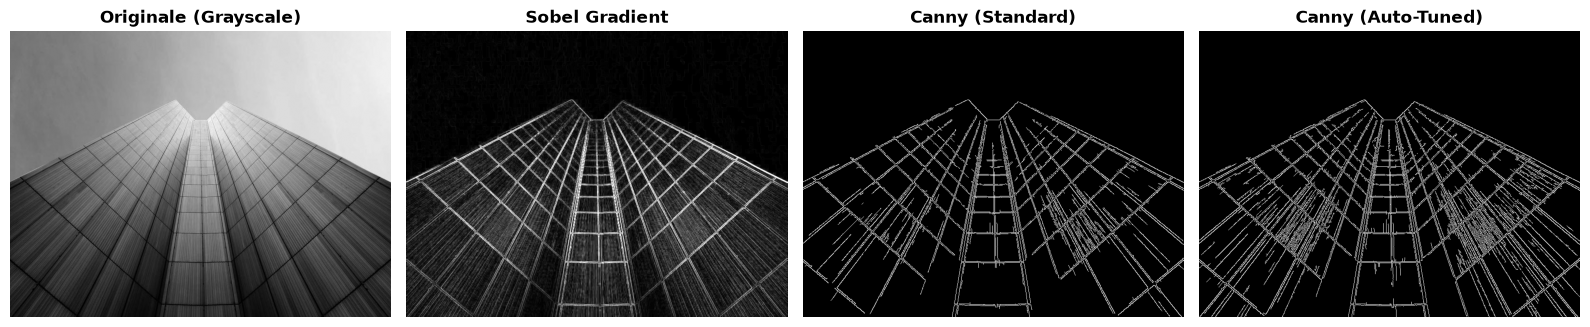

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from pathlib import Path

# Configurazione Best Practice 2026: Integrazione Keras 3 con Backend PyTorch
os.environ["KERAS_BACKEND"] = "torch"
import keras

def analyze_edges_from_url(url: str):
    """
    Scarica un'immagine da internet ed esegue l'analisi dei bordi (Sobel e Canny)
    con esportazione finale in un tensore Keras.
    """
    # 1. CARICAMENTO DA INTERNET
    print(f"[*] Download immagine da: {url}")
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        
        # Trasformiamo i byte della risposta in un array NumPy
        image_array = np.frombuffer(response.content, np.uint8)
        
        # Decodifichiamo direttamente in scala di grigi (IMREAD_GRAYSCALE)
        img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            raise ValueError("Errore nella decodifica dell'immagine.")
    except Exception as e:
        print(f"[-] Errore durante il caricamento: {e}")
        return None

    # 2. CALCOLO DEI GRADIENTI (SOBEL)
    # Calcoliamo le derivate parziali orizzontali e verticali
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    
    # Magnitudo del gradiente (Ipotenusa):
    # G = \sqrt{G_x^2 + G_y^2}
    gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
    gradient_magnitude = np.uint8(np.clip(gradient_magnitude, 0, 255))

    # 3. ALGORITMO DI CANNY (LOGICA MULTI-STADIO)
    # 
    canny_standard = cv2.Canny(img, 100, 200)

    # 4. TUNING AUTOMATICO (AUTO-CANNY)
    # Utilizziamo la mediana per adattare le soglie dinamicamente
    v = np.median(img)
    sigma = 0.33
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    canny_auto = cv2.Canny(img, lower, upper)

    # 5. ESPORTAZIONE VERSO DEEP LEARNING (KERAS 3)
    # Conversione in tensore (H, W, 1) per modelli PyTorch/TensorFlow
    edge_tensor = keras.ops.convert_to_tensor(canny_auto, dtype="float32")
    edge_tensor = keras.ops.expand_dims(edge_tensor, axis=-1)

    # Visualizzazione
    plt.figure(figsize=(16, 8))
    images = [img, gradient_magnitude, canny_standard, canny_auto]
    titles = ['Originale (Grayscale)', 'Sobel Gradient', 'Canny (Standard)', 'Canny (Auto-Tuned)']

    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i], fontweight='bold')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    return edge_tensor

if __name__ == "__main__":
    # Esempio con un'immagine di architettura (perfetta per gli spigoli)
    urban_url = "https://picsum.photos/id/1031/800/600"
    analyze_edges_from_url(urban_url)